# Diabetes Risk Factors: Exploratory Data Analysis

Exploratory analysis of the Pima Indians Diabetes dataset (768 women aged 21+, 8 clinical predictors, binary diabetes outcome).

**Questions**
1. How common is diabetes in this sample, and how does it vary by age and BMI?
2. Which clinical measures are most strongly associated with diabetes?

**Data:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) (originally from the National Institute of Diabetes and Digestive and Kidney Diseases). Place `diabetes.csv` in the same folder as this notebook.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
try:
    df = pd.read_csv("diabetes.csv")
except FileNotFoundError:
    # Fallback when running in Colab without the file in the working directory
    from google.colab import files
    files.upload()
    df = pd.read_csv("diabetes.csv")

print(f"Shape: {df.shape}")
df.head()

Saving diabetes.csv to diabetes.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 1. Data quality

`isnull()` finds no missing values, but in this dataset **missing values are recorded as 0** for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI`. A value of 0 is physiologically impossible for these measures, so they are treated as missing.

In [4]:
print("Formal missing values:", df.isnull().sum().sum())

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[zero_cols] == 0).sum()
pd.DataFrame({"zeros": zero_counts, "percent": (100 * zero_counts / len(df)).round(1)})

Formal missing values: 0


,zeros,percent
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


In [5]:
# Recode impossible zeros as missing, then impute with the column median
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


**Note:** `Insulin` and `SkinThickness` have a large share of missing values, so median imputation shrinks their variability and weakens their correlations. Treat findings for these two variables with caution.

## 2. Outcome distribution

Without diabetes: 500 (65.1%)
With diabetes:    268 (34.9%)


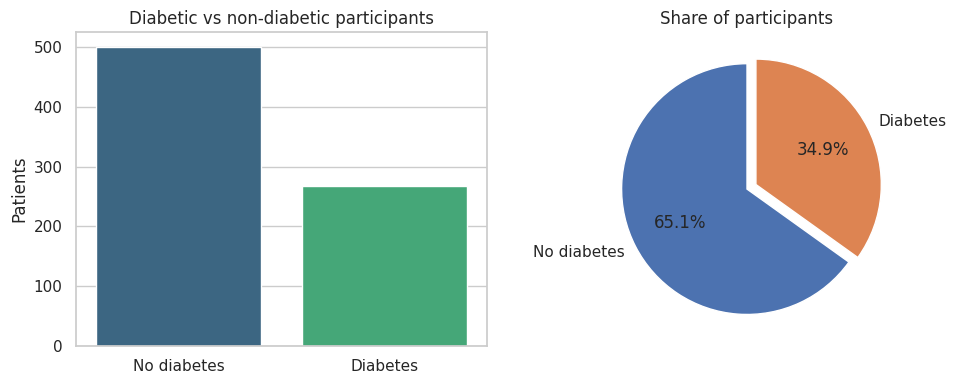

In [6]:
counts = df["Outcome"].value_counts().sort_index()
pct = (100 * counts / len(df)).round(1)
print(f"Without diabetes: {counts[0]} ({pct[0]}%)")
print(f"With diabetes:    {counts[1]} ({pct[1]}%)")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Outcome", hue="Outcome", data=df, palette="viridis", legend=False, ax=ax[0])
ax[0].set_xticks([0, 1], ["No diabetes", "Diabetes"])
ax[0].set_xlabel("")
ax[0].set_ylabel("Patients")
ax[0].set_title("Diabetic vs non-diabetic participants")

ax[1].pie(counts, labels=["No diabetes", "Diabetes"], autopct="%1.1f%%", startangle=90, explode=[0, 0.08])
ax[1].set_title("Share of participants")
plt.tight_layout()
plt.show()

## 3. BMI and diabetes

In [7]:
bmi_bins = [0, 18.5, 25, 30, 40, np.inf]
bmi_labels = ["Underweight", "Healthy", "Overweight", "Obesity", "Severe obesity"]
df["BMICategory"] = pd.cut(df["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)

bmi_summary = (
    df.groupby("BMICategory", observed=True)
      .agg(patients=("Outcome", "size"),
           prevalence_pct=("Outcome", lambda s: 100 * s.mean()),
           mean_bp=("BloodPressure", "mean"))
      .round(1)
)
bmi_summary

,patients,prevalence_pct,mean_bp
BMICategory,,,
Underweight,4,0.0,69.5
Healthy,102,6.9,68.1
Overweight,179,22.3,69.5
Obesity,385,43.1,73.4
Severe obesity,98,56.1,78.1


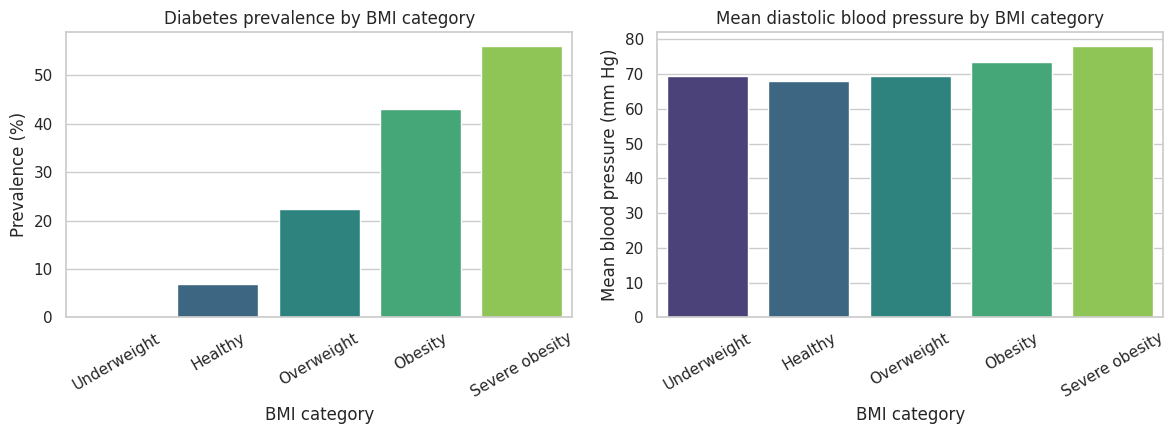

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=bmi_summary.index, y=bmi_summary["prevalence_pct"], hue=bmi_summary.index,
            palette="viridis", legend=False, ax=ax[0])
ax[0].set_title("Diabetes prevalence by BMI category")
ax[0].set_xlabel("BMI category")
ax[0].set_ylabel("Prevalence (%)")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(x=bmi_summary.index, y=bmi_summary["mean_bp"], hue=bmi_summary.index,
            palette="viridis", legend=False, ax=ax[1])
ax[1].set_title("Mean diastolic blood pressure by BMI category")
ax[1].set_xlabel("BMI category")
ax[1].set_ylabel("Mean blood pressure (mm Hg)")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Glucose and diabetes

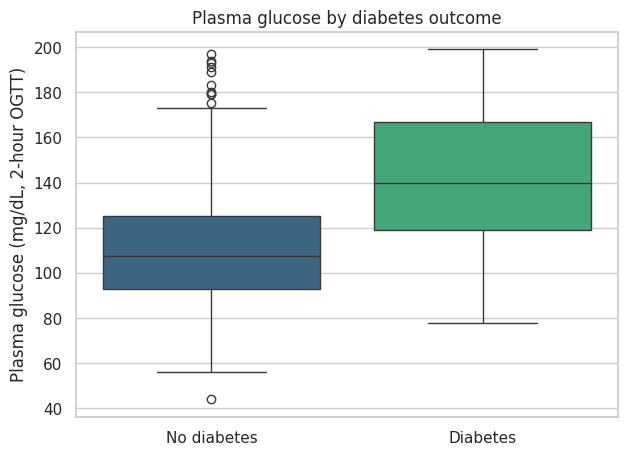

In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Outcome", y="Glucose", hue="Outcome", data=df, palette="viridis", legend=False)
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("Plasma glucose by diabetes outcome")
plt.xlabel("")
plt.ylabel("Plasma glucose (mg/dL, 2-hour OGTT)")
plt.show()

## 5. Age and diabetes

In [10]:
print(f"Mean age:   {df['Age'].mean():.1f}")
print(f"Median age: {df['Age'].median():.1f}")
print(f"Std dev:    {df['Age'].std():.1f}")
print(f"Range:      {df['Age'].min()} to {df['Age'].max()}")

Mean age:   33.2
Median age: 29.0
Std dev:    11.8
Range:      21 to 81


In [11]:
age_bins = [20, 30, 40, 50, 60, 70, 100]
age_labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=False)

age_summary = (
    df.groupby("AgeGroup", observed=True)
      .agg(patients=("Outcome", "size"), prevalence_pct=("Outcome", lambda s: 100 * s.mean()))
      .round(1)
)
age_summary

,patients,prevalence_pct
AgeGroup,,
20-29,396,21.2
30-39,165,46.1
40-49,118,55.1
50-59,57,59.6
60-69,29,27.6
70+,3,33.3


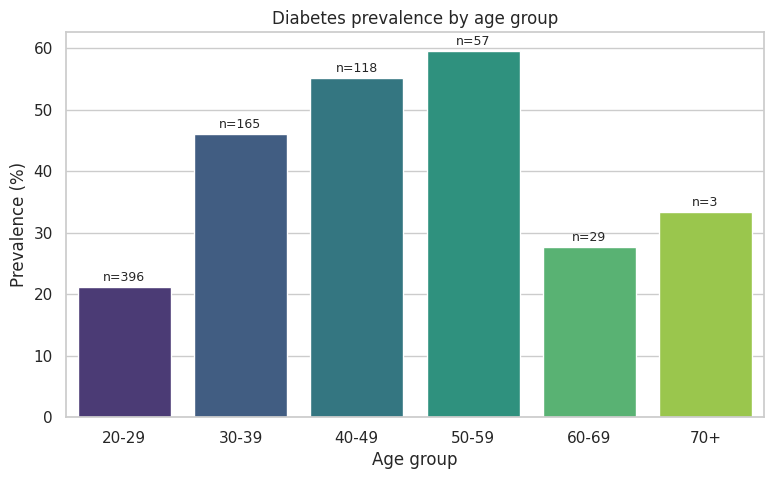

In [12]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=age_summary.index, y=age_summary["prevalence_pct"], hue=age_summary.index,
                 palette="viridis", legend=False)
for i, n in enumerate(age_summary["patients"]):
    ax.text(i, age_summary["prevalence_pct"].iloc[i] + 1, f"n={n}", ha="center", fontsize=9)
plt.title("Diabetes prevalence by age group")
plt.xlabel("Age group")
plt.ylabel("Prevalence (%)")
plt.show()

Older age groups contain few patients, so their prevalence estimates are unstable.

## 6. Correlations

In [13]:
numeric = df.drop(columns=["BMICategory", "AgeGroup"])
corr_outcome = numeric.corr()["Outcome"].drop("Outcome").sort_values(ascending=False).round(2)
corr_outcome

,Outcome
Glucose,0.49
BMI,0.31
Age,0.24
Pregnancies,0.22
SkinThickness,0.21
Insulin,0.20
DiabetesPedigreeFunction,0.17
BloodPressure,0.17


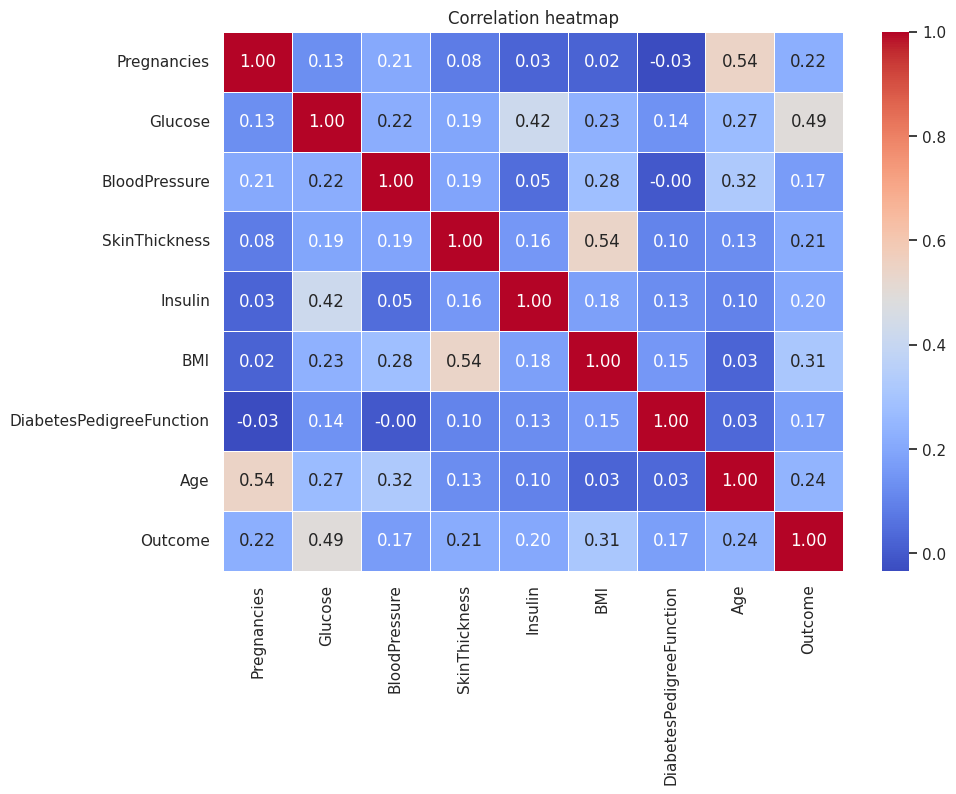

In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation heatmap")
plt.show()

## 7. Key findings

- **Glucose** has the strongest association with diabetes in this sample, followed by **BMI**, **age** and **number of pregnancies**.
- **Blood pressure** and **skin thickness** show only weak associations.
- Prevalence rises with BMI category and differs across age groups; the oldest groups have too few patients for firm conclusions.

## 8. Limitations

- **Association, not causation:** correlations cannot show that any variable causes diabetes.
- **Population:** the sample is female, aged 21 and over, of Pima heritage, so results may not generalise to other populations.
- **Missing data:** many zeros in `Insulin` and `SkinThickness` were imputed with the median, which reduces their apparent association with the outcome.
- **Design:** the data are cross-sectional, so temporal relationships cannot be assessed.
- **Next steps:** logistic regression or tree-based models, with cross-validation and a missing-data-aware approach to imputation.